In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("../data/raw/retail_sales_dataset.csv", parse_dates=["Date"])
print(df.head())

   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [3]:
print(df.shape)
df.info()
print(df.isna().sum())
print(df.duplicated().sum())

(1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
0


In [4]:
df =df.drop_duplicates()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [5]:
df.to_csv("../data/processed/retail_sales_clean.csv", index=False)

In [6]:
print(df.describe())                                          
print(df[["Age","Quantity","Price per Unit","Total Amount"]].mean())
print(df[["Age","Quantity","Price per Unit","Total Amount"]].median())
print(df[["Age","Quantity","Price per Unit","Total Amount"]].std())


       Transaction ID                        Date         Age     Quantity  \
count     1000.000000                        1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000    41.39200     2.514000   
min          1.000000         2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000         2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000         2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000         2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000         2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                         NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.000000    900.000000  
max        500.000000   2000.00

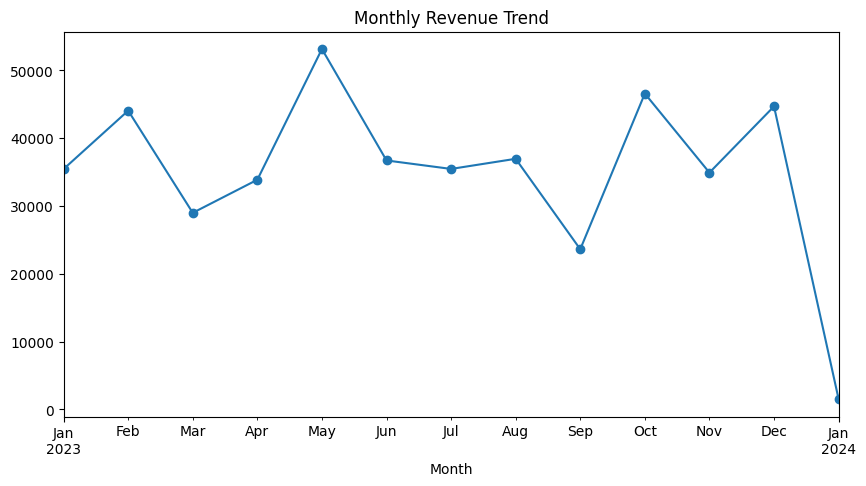

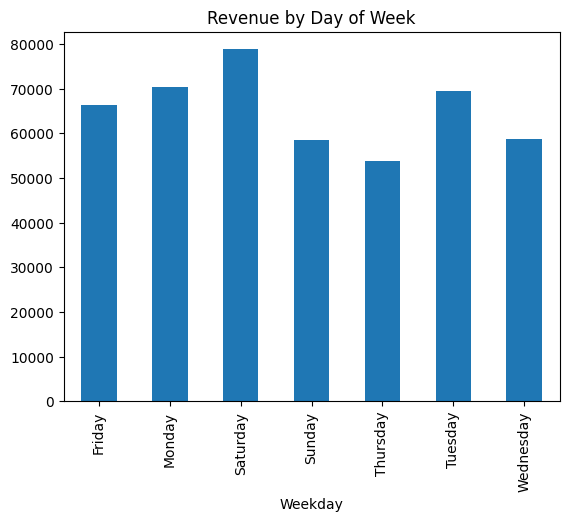

In [7]:
df["Month"] = df["Date"].dt.to_period("M")
monthly = df.groupby("Month")["Total Amount"].sum()
monthly.plot(marker="o", figsize=(10,5), title="Monthly Revenue Trend")
plt.savefig("../charts/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

df["Weekday"] = df["Date"].dt.day_name()
weekday_sales = df.groupby("Weekday")["Total Amount"].sum()
weekday_sales.plot(kind="bar", title="Revenue by Day of Week")
plt.savefig("../charts/revenue_by_weekday.png", bbox_inches="tight")
plt.show()

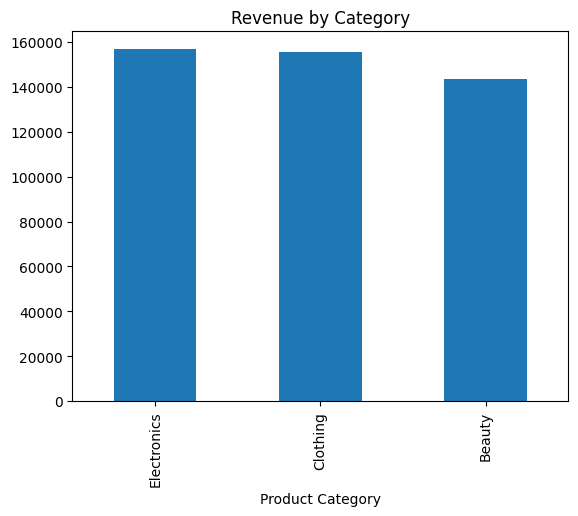

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


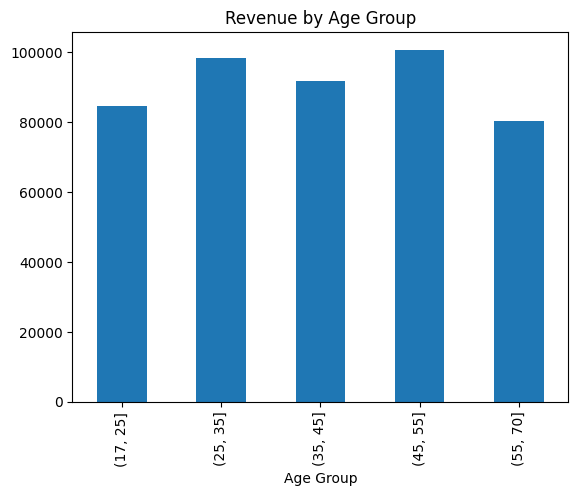

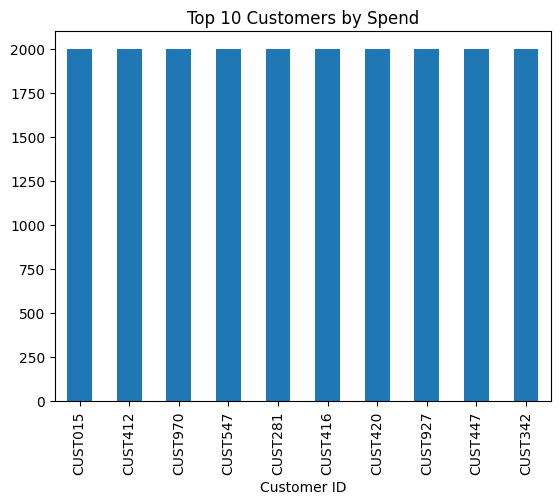

In [8]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False).plot(kind="bar", title="Revenue by Category")
plt.savefig("../charts/revenue_by_category.png", bbox_inches="tight")
plt.show()

print(df.groupby("Gender")["Total Amount"].mean())

age_bins = [17,25,35,45,55,70]
df["Age Group"] = pd.cut(df["Age"], bins=age_bins)
df.groupby("Age Group")["Total Amount"].sum().plot(kind="bar", title="Revenue by Age Group")
plt.show()

top_customers = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar", title="Top 10 Customers by Spend")
plt.savefig("../charts/top_customers.png", bbox_inches="tight")
plt.show()

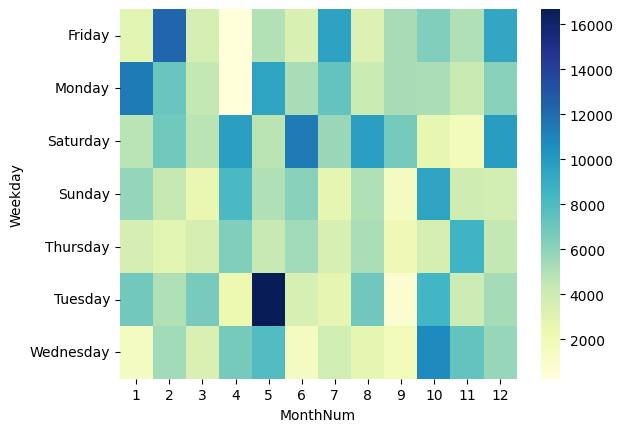

In [9]:

df["MonthNum"] = df["Date"].dt.month
heat = df.pivot_table(index="Weekday", columns="MonthNum", values="Total Amount", aggfunc="sum")
sns.heatmap(heat, cmap="YlGnBu")
plt.savefig("../charts/heatmap_weekday_month.png", bbox_inches="tight")
plt.show()